# 01 · Data Quality Assessment & Cleaning

**Context:** Tata *Data Visualisation* job simulation (Forage). The CEO and CMO of a UK-based online
retailer want four questions answered from their 2010–2011 transaction log (see notebook 02).

**This notebook's goal:** understand the raw data, find what could bias the analysis, then apply the
cleaning rules from the brief and export the dataset used by notebook 02 and the Power BI report.

**Source:** [UCI Online Retail dataset](https://archive.ics.uci.edu/dataset/352/online+retail) (CC BY 4.0).
It holds every transaction of a UK-based online gift retailer between 01/12/2010 and 09/12/2011.
Prices are in pounds sterling (£).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from online_retail import (
    PROCESSED_DATA_PATH,
    add_date_features,
    clean_transactions,
    data_quality_summary,
    download_raw_data,
    load_raw_data,
)
from online_retail.analysis import NON_PRODUCT_STOCK_CODES
from online_retail.plotting import PRIMARY, set_style

set_style()
pd.set_option("display.float_format", "{:,.2f}".format)

## 1. Load the raw data

In [2]:
download_raw_data()  # no-op when the file is already in data/raw/
raw = load_raw_data()

print(f"{raw.shape[0]:,} rows × {raw.shape[1]} columns")
raw.head()

541,909 rows × 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


| Column | Description |
|---|---|
| `InvoiceNo` | Invoice number. A leading **C** marks a cancellation |
| `StockCode` | Product code. Some codes are fees or postage, not products |
| `Description` | Product name |
| `Quantity` | Units per line (negative for cancellations and returns) |
| `InvoiceDate` | Date and time of the transaction |
| `UnitPrice` | Price per unit in £ |
| `CustomerID` | Anonymised customer identifier |
| `Country` | Customer's country of residence |

Identifiers are loaded as **text** (`InvoiceNo`, `StockCode`) or **nullable integers** (`CustomerID`).
This keeps the `C` prefix and avoids `17850.0`-style float IDs.

In [3]:
raw.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID              Int64
Country                   str
dtype: object

## 2. Data quality overview

In [4]:
data_quality_summary(raw)

,Rows,% of rows
Exact duplicate rows,5268,0.97
Missing CustomerID,135080,24.93
Missing Description,1454,0.27
Cancellation invoices (InvoiceNo starts with 'C'),9288,1.71
Quantity < 1,10624,1.96
UnitPrice < 0,2,0.00
UnitPrice = 0,2515,0.46
"Non-product lines (postage, fees, adjustments)",2911,0.54


**Takeaways**
- **~25 % of lines have no `CustomerID`.** They are real sales (guest checkouts), so they stay in the
  revenue analysis but drop out of the customer analysis (Q3).
- **Cancellations and returns** show up as negative quantities. The brief removes them.
- **Exact duplicate rows** (~1 %) can't be told apart from a real repeat line on the same invoice.
  They are kept to match the brief. Their impact is measured below.
- **Non-product lines** (postage, Amazon fees, manual adjustments) are mixed in with product sales.

## 3. Period covered

In [5]:
print(f"From {raw['InvoiceDate'].min():%d %b %Y} to {raw['InvoiceDate'].max():%d %b %Y}")

lines_per_month = raw.groupby(raw["InvoiceDate"].dt.to_period("M")).size().rename("Lines")
lines_per_month.to_frame().T

From 01 Dec 2010 to 09 Dec 2011


InvoiceDate,2010-12,2011-01,2011-02,2011-03,2011-04,2011-05,2011-06,2011-07,2011-08,2011-09,2011-10,2011-11,2011-12
Lines,42481,35147,27707,36748,29916,37030,36874,39518,35284,50226,60742,84711,25525


The data covers **13 months**. December 2011 stops on the 9th, so **December 2011 is a partial month**.
Monthly comparisons have to account for that (see Q1 in notebook 02).

## 4. Negative quantities: cancellations vs. stock adjustments

In [6]:
invoice_type = raw["InvoiceNo"].str.startswith("C").map({True: "Cancellation (C…)", False: "Regular invoice"})
quantity_sign = (raw["Quantity"] < 1).map({True: "Quantity < 1", False: "Quantity ≥ 1"})

pd.crosstab(invoice_type, quantity_sign, margins=True)

Quantity,Quantity < 1,Quantity ≥ 1,All
InvoiceNo,,,
Cancellation (C…),9288,0,9288
Regular invoice,1336,531285,532621
All,10624,531285,541909


In [7]:
adjustments = raw[(raw["Quantity"] < 1) & ~raw["InvoiceNo"].str.startswith("C")]

print(f"Regular invoices with Quantity < 1: {len(adjustments):,} lines")
print(f"  UnitPrice always 0 : {(adjustments['UnitPrice'] == 0).all()}")
print(f"  CustomerID missing : {adjustments['CustomerID'].isna().all()}")
adjustments["Description"].value_counts().head(8)

Regular invoices with Quantity < 1: 1,336 lines
  UnitPrice always 0 : True
  CustomerID missing : True


Description
check                     120
damages                    45
damaged                    42
?                          41
sold as set on dotcom      20
Damaged                    14
thrown away                 9
Unsaleable, destroyed.      9
Name: count, dtype: int64

Every cancellation has a negative quantity. The remaining ~1,300 negative lines are **zero-priced stock
adjustments** with no customer ("check", "damaged", "thrown away"…). The `Quantity ≥ 1` rule therefore
removes both groups, and since they have no value, revenue isn't affected.

## 5. Outliers

In [8]:
columns = ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID", "InvoiceDate"]
bulk_codes = raw.nlargest(2, "Quantity")["StockCode"]

raw[raw["StockCode"].isin(bulk_codes) & (raw["Quantity"].abs() > 70_000)][columns]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,InvoiceDate
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346,2011-01-18 10:01:00
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.04,12346,2011-01-18 10:17:00
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446,2011-12-09 09:15:00
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.08,16446,2011-12-09 09:27:00


The two largest orders (80,995 and 74,215 units) were **cancelled within minutes**. The brief's rule drops
the cancellation line (negative quantity) but **keeps the original order**. That adds **£245k of revenue
that was never earned** and puts two customers in the Top 10 (addressed in Q3).

In [9]:
raw.nlargest(8, "UnitPrice")[columns]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,InvoiceDate
222681,C556445,M,Manual,-1,"38,970.00",15098,2011-06-10 15:31:00
524602,C580605,AMAZONFEE,AMAZON FEE,-1,"17,836.46",<NA>,2011-12-05 11:36:00
43702,C540117,AMAZONFEE,AMAZON FEE,-1,"16,888.02",<NA>,2011-01-05 09:55:00
43703,C540118,AMAZONFEE,AMAZON FEE,-1,"16,453.71",<NA>,2011-01-05 09:57:00
15016,C537630,AMAZONFEE,AMAZON FEE,-1,"13,541.33",<NA>,2010-12-07 15:04:00
15017,537632,AMAZONFEE,AMAZON FEE,1,"13,541.33",<NA>,2010-12-07 15:08:00
16356,C537651,AMAZONFEE,AMAZON FEE,-1,"13,541.33",<NA>,2010-12-07 15:49:00
16232,C537644,AMAZONFEE,AMAZON FEE,-1,"13,474.79",<NA>,2010-12-07 15:34:00


In [10]:
non_product = raw[raw["StockCode"].isin(NON_PRODUCT_STOCK_CODES)]
(
    non_product.assign(Revenue=non_product["Quantity"] * non_product["UnitPrice"])
    .groupby(["StockCode", "Description"])
    .agg(Lines=("Revenue", "size"), Revenue=("Revenue", "sum"))
    .sort_values("Lines", ascending=False)
)

,,Lines,Revenue
StockCode,Description,,
POST,POSTAGE,1252,"66,230.64"
DOT,DOTCOM POSTAGE,709,"206,245.48"
M,Manual,571,"-68,674.19"
C2,CARRIAGE,143,"6,986.00"
D,Discount,77,"-5,696.22"
S,SAMPLES,63,"-3,049.39"
BANK CHARGES,Bank Charges,37,"-7,175.64"
AMAZONFEE,AMAZON FEE,34,"-221,520.50"
CRUK,CRUK Commission,16,"-7,933.43"


The highest unit prices are **not products**: they are Amazon fees, manual adjustments and bad-debt write-offs.
After cleaning, the positive non-product lines (mostly postage `POST`/`DOT`, plus some manual entries and fees)
still add revenue. It's a small share (~4 %), but something to keep in mind when reading "revenue" as "product sales".

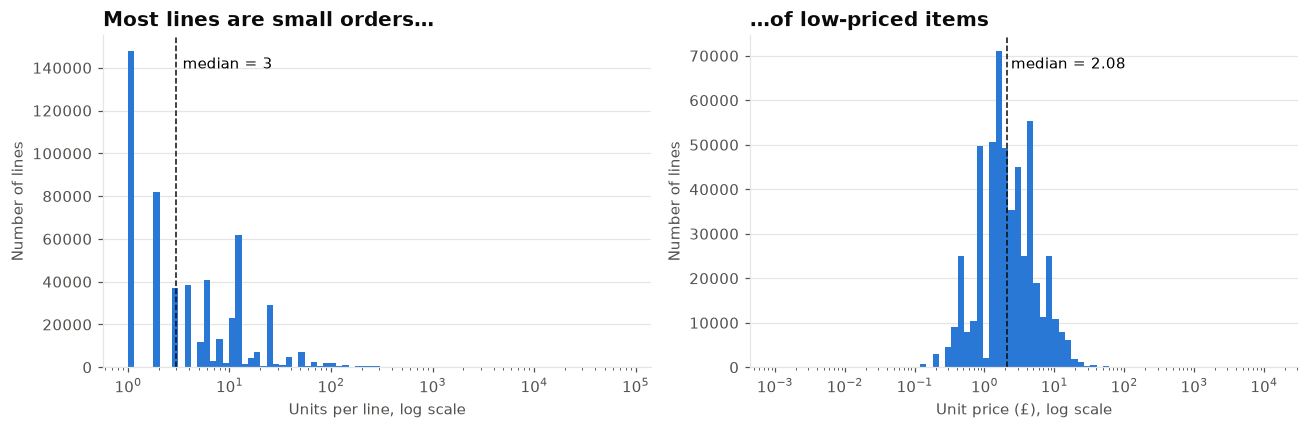

,count,mean,std,min,50%,99%,max
Quantity,"530,104.00",10.54,155.52,1.00,3.00,100.00,"80,995.00"
UnitPrice,"530,104.00",3.91,35.92,0.00,2.08,16.98,"13,541.33"


In [11]:
valid = raw[(raw["Quantity"] >= 1) & (raw["UnitPrice"] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, column, label in [
    (axes[0], "Quantity", "Units per line"),
    (axes[1], "UnitPrice", "Unit price (£)"),
]:
    log_bins = np.logspace(np.log10(valid[column].min()), np.log10(valid[column].max()), 80)
    ax.hist(valid[column], bins=log_bins, color=PRIMARY)
    ax.axvline(valid[column].median(), color="#0b0b0b", linestyle="--", linewidth=1)
    ax.text(valid[column].median() * 1.15, ax.get_ylim()[1] * 0.9, f"median = {valid[column].median():g}")
    ax.set_xscale("log")
    ax.set_xlabel(f"{label}, log scale")
    ax.set_ylabel("Number of lines")
    ax.grid(axis="x", visible=False)
axes[0].set_title("Most lines are small orders…")
axes[1].set_title("…of low-priced items")
fig.tight_layout()
plt.show()

valid[["Quantity", "UnitPrice"]].describe(percentiles=[0.5, 0.99]).T

Both variables are **heavily right-skewed**: the median line is 3 units at about £2, while the
maximums are thousands of times larger. Medians and totals are therefore more reliable than means here.
Outliers are **kept** unless they are known errors: large B2B orders are part of this wholesaler-like business.

## 6. Apply the cleaning rules

Rules from the business brief:
1. Remove lines with `Quantity < 1` (cancellations, returns, stock adjustments)
2. Remove lines with `UnitPrice < 0` (bad-debt adjustments)
3. Compute `Revenue = Quantity × UnitPrice`
4. Add calendar columns (`Year`, `Month`, `Month_Name`, `Year_Month`) for the analysis and Power BI

In [12]:
clean = add_date_features(clean_transactions(raw))

removed = pd.Series(
    {
        "Quantity < 1": (raw["Quantity"] < 1).sum(),
        "UnitPrice < 0 (and Quantity ≥ 1)": ((raw["UnitPrice"] < 0) & (raw["Quantity"] >= 1)).sum(),
    },
    name="Rows removed",
)
display(removed.to_frame())

print(f"Raw rows   : {len(raw):,}")
print(f"Clean rows : {len(clean):,} ({len(clean) / len(raw):.1%} kept)")
print(f"Revenue    : £{clean['Revenue'].sum():,.0f}")
assert (clean["Quantity"] >= 1).all() and (clean["UnitPrice"] >= 0).all()

,Rows removed
Quantity < 1,10624
UnitPrice < 0 (and Quantity ≥ 1),2


Raw rows   : 541,909
Clean rows : 531,283 (98.0% kept)
Revenue    : £10,666,685


### Impact of the remaining issues (kept, but quantified)

In [13]:
total_revenue = clean["Revenue"].sum()
duplicate_lines = clean[clean.drop(columns=["Revenue"]).duplicated()]
bulk_orders = clean[clean["Quantity"] > 70_000]
non_product_lines = clean[clean["StockCode"].isin(NON_PRODUCT_STOCK_CODES)]

impact = pd.DataFrame(
    {
        "Rows": [len(duplicate_lines), len(bulk_orders), len(non_product_lines), (clean["UnitPrice"] == 0).sum(),
                 clean["CustomerID"].isna().sum()],
        "Revenue (£)": [duplicate_lines["Revenue"].sum(), bulk_orders["Revenue"].sum(),
                        non_product_lines["Revenue"].sum(), 0,
                        clean.loc[clean["CustomerID"].isna(), "Revenue"].sum()],
    },
    index=["Exact duplicate lines", "Bulk orders cancelled right after", "Postage, fees & manual entries",
           "Zero-price lines (free items)", "Unknown customer"],
)
impact["% of revenue"] = impact["Revenue (£)"] / total_revenue * 100
impact

,Rows,Revenue (£),% of revenue
Exact duplicate lines,5231,"24,573.74",0.23
Bulk orders cancelled right after,2,"245,653.20",2.30
"Postage, fees & manual entries",2325,"394,563.12",3.70
Zero-price lines (free items),1179,0.00,0.00
Unknown customer,133359,"1,755,276.64",16.46


Duplicates, cancelled bulk orders and non-product lines together are **about 6 % of revenue**. They don't change the
country and monthly conclusions, but they do distort the **customer ranking**, which notebook 02 corrects for.
Unknown customers represent **~16 % of revenue**, so the customer analysis covers about 84 % of sales.

## 7. Export

In [14]:
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
clean.to_csv(PROCESSED_DATA_PATH, index=False)
print(f"Saved {len(clean):,} rows to {PROCESSED_DATA_PATH.relative_to(PROCESSED_DATA_PATH.parents[2])}")

Saved 531,283 rows to data\processed\online_retail_clean.csv


## Assumptions & limitations

| Topic | Decision / limitation |
|---|---|
| Cleaning rules | The brief's rules (`Quantity ≥ 1`, `UnitPrice ≥ 0`), applied as-is so the numbers match the Power BI report |
| Cancelled bulk orders | Kept by the brief's rules (+£245k). Corrected in the customer analysis using **net revenue** |
| Duplicate lines | Kept: can't be told apart from real repeat lines (0.2 % of revenue) |
| Missing `CustomerID` | Kept for revenue and country analysis, excluded for customer ranking (16 % of revenue) |
| Postage, fees & manual entries | Counted as revenue, as in the brief (~4 % of revenue) |
| Period | Dec 2011 covers only 1–9 Dec. Dec 2010 is excluded from the 2011 analysis |
| Currency | All amounts in £, not adjusted for inflation |
| Country | Customer's country of residence, not the shipping destination. Includes "Unspecified" and "European Community" |

The same pipeline can be run without Jupyter: `python -m online_retail`.